In [2]:
import os
import torch
from PIL import Image
from torchvision import transforms
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [6]:
%matplotlib inline

In [3]:
model = torch.hub.load('C:/Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/yolov5', 'custom', path='C:/Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/best.pt', source='local')
model.conf=0.3

YOLOv5  v7.0-368-gb163ff8d Python-3.10.14 torch-2.4.1+cpu CPU

Fusing layers... 
YOLOv5s summary: 157 layers, 7012822 parameters, 0 gradients, 15.8 GFLOPs
Adding AutoShape... 


In [4]:
# 비디오 열기
mp4Path = 'C:/Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/test_cctv2.mp4'
cap=cv2.VideoCapture(mp4Path)
fps = cap.get(cv2.CAP_PROP_FPS)              # 초당 프레임 수
frame_count = cap.get(cv2.CAP_PROP_FRAME_COUNT)  # 총 프레임 수
width = cap.get(cv2.CAP_PROP_FRAME_WIDTH)    # 비디오의 너비
height = cap.get(cv2.CAP_PROP_FRAME_HEIGHT)  # 비디오의 높이

framelist=[]
resultlist=[]

while(True):
    retval, frame = cap.read()
    cv2.imshow('frame',frame)
    result = model(frame,size=1920)
    framelist.append(frame)
    resultlist.append(result)
    key = cv2.waitKey(int(1000/30))
    if key==27:
        break

if cap.isOpened():
    cap.release()

cv2.destroyAllWindows()

# 프레임 마다 객체인식

# 이전 정보 바탕으로 객체 추적 및 속도 계산

# 교통량 및 속도 저장 한 것을 그래프 그리기

C:\Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/yolov5\models\common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/yolov5\models\common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/yolov5\models\common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/yolov5\models\common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):
C:\Users/User.DESKTOP-5C3VHRV/opencv

KeyboardInterrupt: 

In [21]:
img=Image.open('C:/Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/newimage3.png')
result=model(img,size=1920)

C:\Users/User.DESKTOP-5C3VHRV/opencv/opencv_study/comento/yolov5\models\common.py:892: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(autocast):


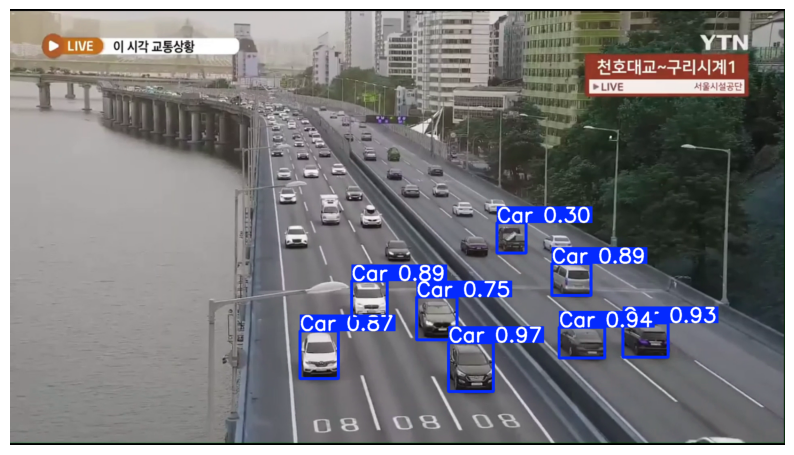

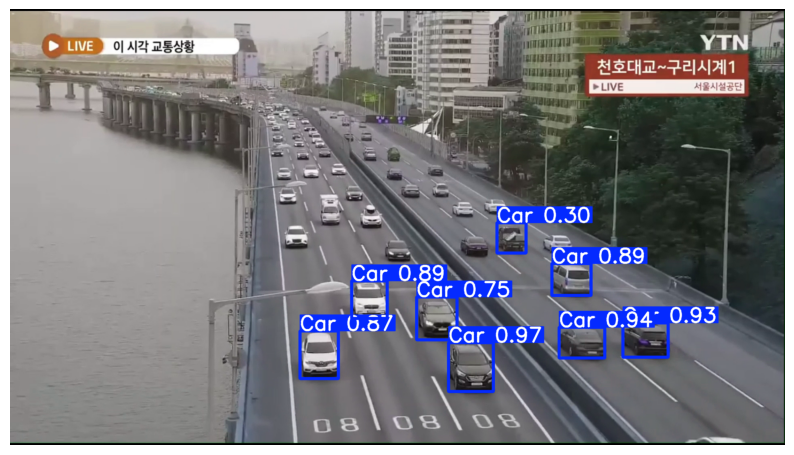

In [7]:
# 추론 결과 확인하기
#print(results.pandas().xyxy[0])
result=resultlist[30]

# Save or display results

plt.figure(figsize=(10,6))
plt.imshow(result.render()[0])
plt.axis('off')
plt.show()

In [9]:
resultlist[0].pandas().xyxy[0]

,xmin,ymin,xmax,ymax,confidence,class,name
0,1152.807983,930.826782,1269.773071,1052.531616,0.962664,0,Car
1,1467.704834,720.656372,1587.685547,817.825684,0.940787,0,Car
2,901.660400,850.517334,1005.948608,957.688843,0.843009,0,Car


In [10]:
resultlist[1].pandas().xyxy[0]

,xmin,ymin,xmax,ymax,confidence,class,name
0,1152.893921,930.987427,1269.839722,1052.516724,0.962973,0,Car
1,1467.979126,719.894653,1587.526978,817.525879,0.927951,0,Car
